# Modelo de Red Neuronal Convolucional (CNN) para el Reconocimiento de Dígitos

**Objetivo: Desarrollar una CNN que identifique dígitos (0-9) con alta precisión y bajo tiempo de inferencia.**

In [8]:
%pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ----------- ---------------------------- 12.1/40.2 MB 58.1 MB/s eta 0:00:01
   ------------------------------- -------- 32.0/40.2 MB 78.1 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 82.2 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 54.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## PROCESAMIENTO DE DATOS

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt
import numpy as np

# 2.1 Carga de Datos (MNIST)
(x_train_full, y_train_full), (x_test, y_test) = datasets.mnist.load_data()

# 2.3 Limpieza y Preprocesamiento
# Normalización: Escalamos de [0, 255] a [0, 1] para estabilidad (Teoría Sec. 6)
x_train_full = x_train_full.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Redimensionamiento: Añadir canal de color (n, 28, 28, 1)
x_train_full = np.expand_dims(x_train_full, -1)
x_test = np.expand_dims(x_test, -1)

# 2.4 División de Datos (70% Train, 15% Val, 15% Test)
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

print(f"Set de Entrenamiento: {x_train.shape}")
print(f"Set de Validación: {x_val.shape}")

Set de Entrenamiento: (51000, 28, 28, 1)
Set de Validación: (9000, 28, 28, 1)


## MODELO LIGERO

In [20]:
model_base = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"), # Detector de bordes
    layers.MaxPooling2D((2, 2)),                  # Reducción de resolución
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")        # 10 clases (0-9)
])

model_base.compile(optimizer="adam", 
                   loss="sparse_categorical_crossentropy", 
                   metrics=["accuracy"])

## DROPOUT PARA EVITAR OVERFITTING Y DATA AUGMENTATION

In [21]:
# Aumento de datos (Práctica Sec. 2.3)
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model_improved = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3), # Regularización
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_improved.compile(optimizer="adam", 
                      loss="sparse_categorical_crossentropy", 
                      metrics=["accuracy"])

## ENTRENAMIENTO

In [22]:
# Entrenamiento con Early Stopping (Práctica Sec. 4.2)
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

history = model_improved.fit(
    x_train, y_train, 
    epochs=15, 
    batch_size=64, 
    validation_data=(x_val, y_val),
    callbacks=[callback]
)

Epoch 1/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9043 - loss: 0.3080 - val_accuracy: 0.9744 - val_loss: 0.0795
Epoch 2/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9645 - loss: 0.1111 - val_accuracy: 0.9789 - val_loss: 0.0690
Epoch 3/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9738 - loss: 0.0842 - val_accuracy: 0.9857 - val_loss: 0.0518
Epoch 4/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9776 - loss: 0.0699 - val_accuracy: 0.9854 - val_loss: 0.0516
Epoch 5/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9806 - loss: 0.0628 - val_accuracy: 0.9863 - val_loss: 0.0437
Epoch 6/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9824 - loss: 0.0559 - val_accuracy: 0.9880 - val_loss: 0.0393
Epoch 7/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9840 - loss: 0.0514 - val_accuracy: 0.9889 - val_loss: 0.0423
Epoch 8/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9844 - loss: 0.0494 - 

## VISUALIZAR CURVAS

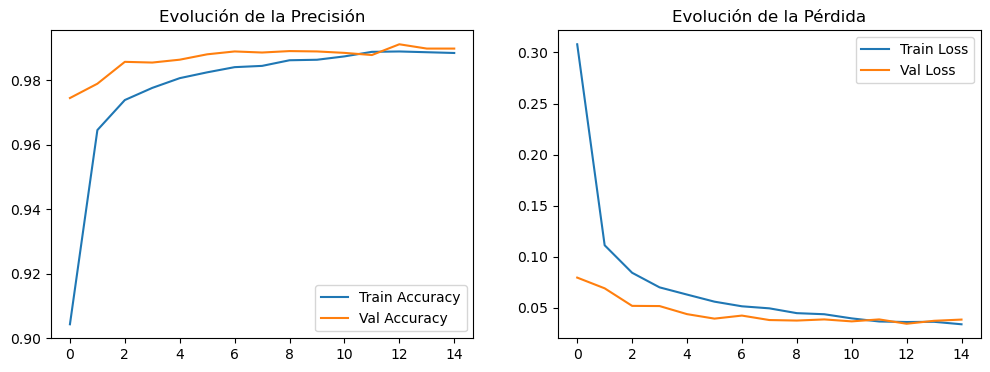

In [23]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Evolución de la Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Evolución de la Pérdida')
plt.legend()
plt.show()

## DEPLOYMENT

In [24]:
# 6.1 Guardado del Modelo (Práctica Sec. 6.1)
model_improved.save("modelo_digitos_postal.keras")
print("Modelo guardado exitosamente como .keras")

Modelo guardado exitosamente como .keras


## PRUEBAS DE MODELO

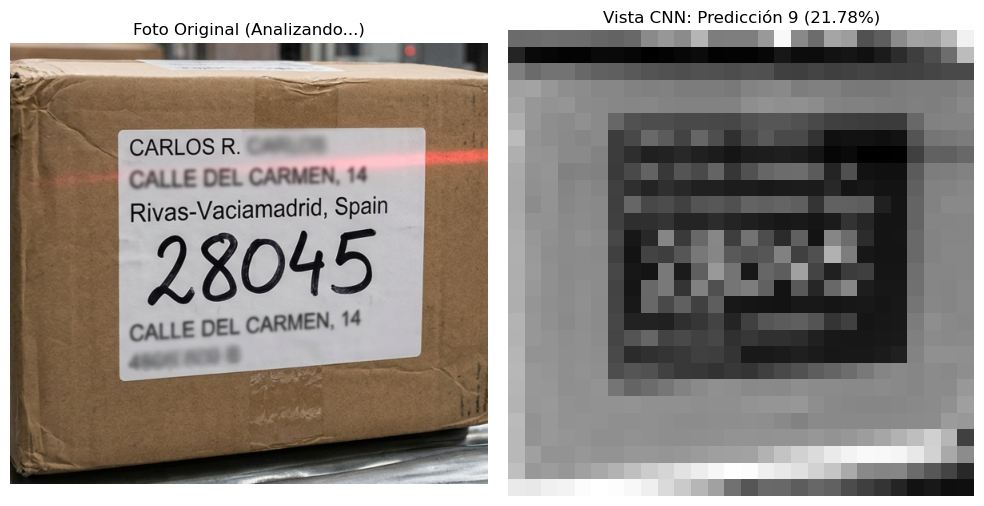

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def probar_mi_imagen(ruta_imagen):
    # 1. Cargar el modelo
    model = load_model("modelo_digitos_postal.keras")
    
    # 2. Leer imagen original (en color para la visualización)
    img_color = cv2.imread(ruta_imagen)
    if img_color is None:
        print(f"No se encuentra la imagen en: {ruta_imagen}")
        return
    
    # Convertir a escala de grises para el procesamiento
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # 3. Preprocesamiento estilo MNIST
    # Redimensionar a 28x28
    img_resized = cv2.resize(img_gray, (28, 28), interpolation=cv2.INTER_AREA)
    # Invertir: MNIST usa fondo negro y trazo blanco
    img_inverted = cv2.bitwise_not(img_resized) 
    
    # 4. Preparar tensor para la CNN (Batch, Alto, Ancho, Canal)
    img_final = img_inverted.astype("float32") / 255.0
    img_final = np.expand_dims(img_final, axis=(0, -1))
    
    # 5. Predicción e Inferencia
    prediccion = model.predict(img_final, verbose=0)
    clase = np.argmax(prediccion)
    confianza = np.max(prediccion) * 100
    
    # 6. Visualización comparativa
    plt.figure(figsize=(10, 5))

    # Subplot 1: Foto original (Entrada del sistema)
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
    plt.title("Foto Original (Analizando...)")
    plt.axis('off')

    # Subplot 2: Imagen procesada (Lo que entra a la CNN)
    plt.subplot(1, 2, 2)
    plt.imshow(img_inverted, cmap='gray')
    plt.title(f"Vista CNN: Predicción {clase} ({confianza:.2f}%)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Ejecución
probar_mi_imagen("mi_paquete.png") # <- Cambiar para ejecutar fotos

### NÚMEROS DE FORMA INDIVIDUAL

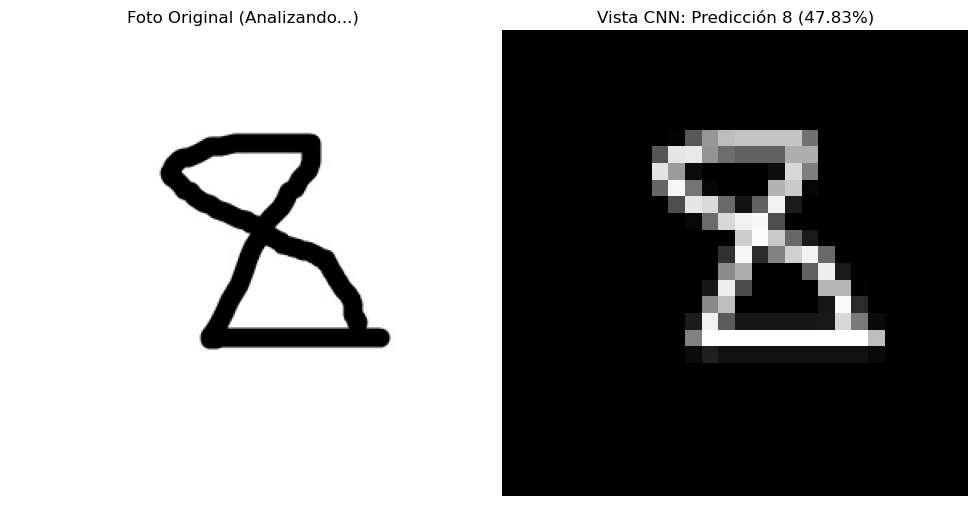

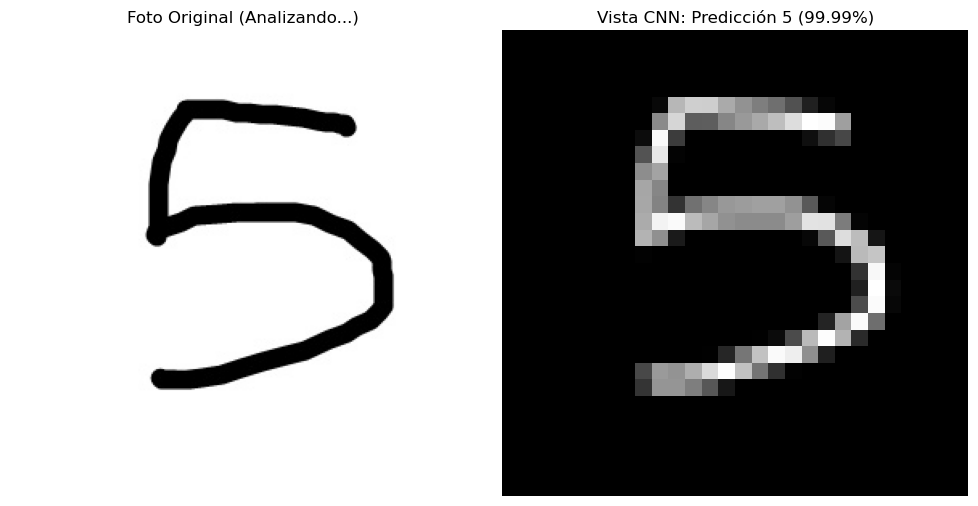

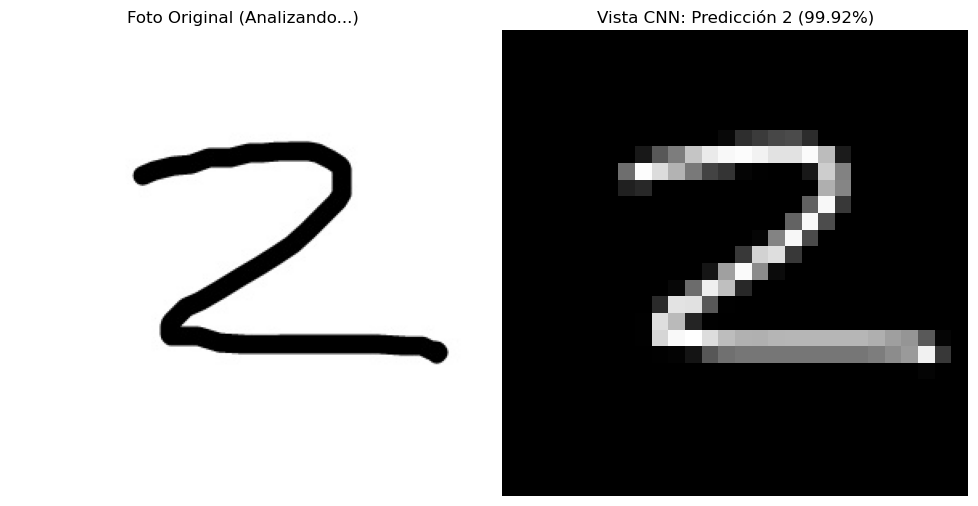

In [26]:
probar_mi_imagen("ocho.jpg")
probar_mi_imagen("cinco.jpg")
probar_mi_imagen("dos.jpg")

### NÚMEROS COMPLICADOS

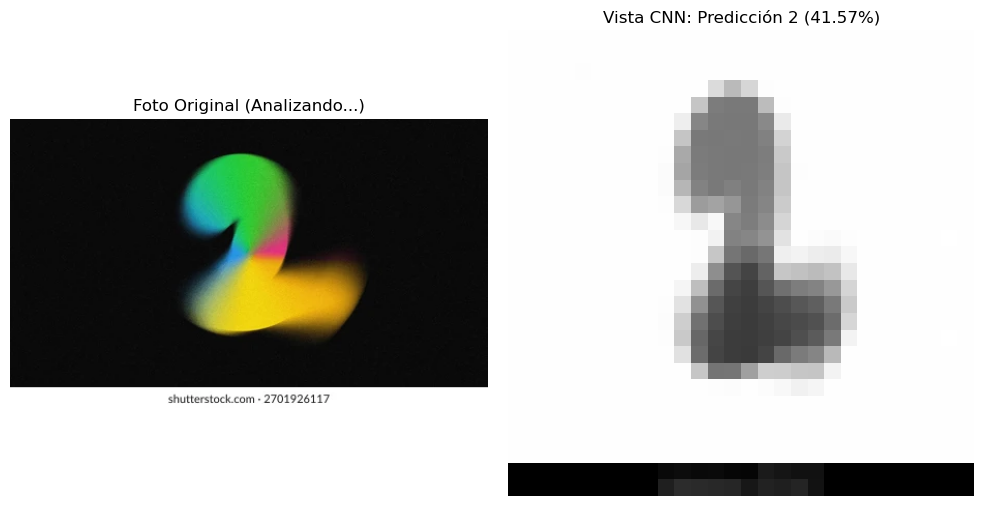

In [29]:
probar_mi_imagen("dos_borroso.webp")